# 01 — Pipeline validation on E1A

End-to-end validation of the processing pipeline using E1A (supine pre-sleep,
5-min analysis window).

**Two processing paths compared side-by-side:**

| path  | filter    | detection                      | correction                        | HRV                              |
|-------|-----------|--------------------------------|-----------------------------------|----------------------------------|
| scipy | filter_ecg | detect_qrs (Pan-Tompkins port) | reject_artifacts 300–2000 ms      | time_domain + frequency_domain   |
| NK2   | filter_ecg | detect_qrs_nk (ecg_peaks)      | signal_fixpeaks (Kubios iterative)| compute_hrv_full (~95 indices)   |

**Expected (competitive swimmer, supine):**
- Mean HR 50-65 bpm
- SDNN >= 50 ms
- Dominant HF peak in 0.2-0.3 Hz band
- EDR rate consistent across peak-detection and Welch-peak methods

In [1]:
from __future__ import annotations

import sys
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src import config as cfg
from src import pipeline as P
from src import plotting as PL

PL.apply_style()
warnings.filterwarnings('ignore', category=RuntimeWarning)

FIG_DIR = REPO_ROOT / 'outputs' / 'figures'
TBL_DIR = REPO_ROOT / 'outputs' / 'tables'
FIG_DIR.mkdir(parents=True, exist_ok=True)
TBL_DIR.mkdir(parents=True, exist_ok=True)
print('Setup complete. Sessions available:', len(cfg.SESSION_MAP))

Setup complete. Sessions available: 14


## 1. Load + filter

In [2]:
key = "E1A"
t, ecg_raw = P.load_ecg(key, ch=1)
ecg_f = P.filter_ecg(ecg_raw)
print(f"{key}: {ecg_raw.size} samples = {ecg_raw.size/cfg.FS:.1f}s")

E1A: 150000 samples = 300.0s


## 2. scipy Pan-Tompkins path

In [3]:
peaks_s = P.detect_qrs(ecg_f)
rr_s, rt_s = P.compute_rr(peaks_s)
rr_s, rt_s, n_rej = P.reject_artifacts(rr_s, rt_s)
td_scipy = P.time_domain_hrv(rr_s)
fd_scipy = P.frequency_domain_hrv(rr_s, rt_s)
print(f"scipy: {peaks_s.size} peaks, {n_rej} RR rejected")
print(f"  Mean HR = {td_scipy['mean_hr_bpm']:.1f} bpm")
print(f"  SDNN    = {td_scipy['sdnn_ms']:.1f} ms")
print(f"  RMSSD   = {td_scipy['rmssd_ms']:.1f} ms")

scipy: 269 peaks, 0 RR rejected
  Mean HR = 54.0 bpm
  SDNN    = 81.5 ms
  RMSSD   = 99.1 ms


## 3. NeuroKit2 path (authoritative)

In [4]:
peaks_nk, nk_stats = P.detect_qrs_nk(ecg_f)
rr_nk, rt_nk = P.compute_rr(peaks_nk)
hrv_full = P.compute_hrv_full(peaks_nk)
print("NK2 peak-detection stats:")
for k, v in nk_stats.items():
    print(f"  {k:20s}: {v}")
print(f"\ncompute_hrv_full: shape={hrv_full.shape}  (indices={hrv_full.shape[1]})")

NK2 peak-detection stats:
  n_peaks_raw         : 268
  n_peaks_corrected   : 268
  ectopic             : 0
  missed              : 0
  extra               : 0
  longshort           : 1
  method              : nk.ecg_peaks + signal_fixpeaks(kubios, iterative=True)

compute_hrv_full: shape=(1, 95)  (indices=95)


## 4. Peak agreement between paths

In [5]:
# Match peaks within a 100 ms window for a fair agreement count
tol = int(0.10 * cfg.FS)
matched = 0
i_nk = 0
for p in peaks_s:
    while i_nk < peaks_nk.size and peaks_nk[i_nk] < p - tol:
        i_nk += 1
    if i_nk < peaks_nk.size and abs(peaks_nk[i_nk] - p) <= tol:
        matched += 1
agreement = 100.0 * matched / max(peaks_s.size, peaks_nk.size)
print(f"scipy peaks: {peaks_s.size}   NK2 peaks: {peaks_nk.size}")
print(f"Matched within {tol} samples (+/-100ms): {matched}")
print(f"Agreement: {agreement:.1f} %")

scipy peaks: 269   NK2 peaks: 268
Matched within 50 samples (+/-100ms): 268
Agreement: 99.6 %


## 5. Side-by-side HRV comparison

In [6]:
# Canonical overlap indices
comp_rows = [
    ("Mean RR (ms)",  td_scipy["mean_rr_ms"],
     float(hrv_full["HRV_MeanNN"].iloc[0]) if "HRV_MeanNN" in hrv_full else np.nan),
    ("Mean HR (bpm)", td_scipy["mean_hr_bpm"],
     60000.0 / float(hrv_full["HRV_MeanNN"].iloc[0]) if "HRV_MeanNN" in hrv_full else np.nan),
    ("SDNN (ms)",     td_scipy["sdnn_ms"],
     float(hrv_full["HRV_SDNN"].iloc[0])  if "HRV_SDNN" in hrv_full  else np.nan),
    ("RMSSD (ms)",    td_scipy["rmssd_ms"],
     float(hrv_full["HRV_RMSSD"].iloc[0]) if "HRV_RMSSD" in hrv_full else np.nan),
    ("pNN50 (%)",     td_scipy["pnn50_pct"],
     float(hrv_full["HRV_pNN50"].iloc[0]) if "HRV_pNN50" in hrv_full else np.nan),
    ("LF/HF (ratio)", fd_scipy["lf_hf_ratio"],
     float(hrv_full["HRV_LFHF"].iloc[0])  if "HRV_LFHF" in hrv_full  else np.nan),
]
df_cmp = pd.DataFrame(comp_rows, columns=["metric", "scipy", "NK2"])
df_cmp["abs_delta"] = (df_cmp["scipy"] - df_cmp["NK2"]).abs()
df_cmp["rel_delta_pct"] = 100.0 * df_cmp["abs_delta"] / df_cmp[["scipy","NK2"]].abs().mean(axis=1)
df_cmp.style.set_caption("E1A — scipy vs NeuroKit2 HRV indices (overlap)").format(
    {"scipy":"{:.2f}","NK2":"{:.2f}","abs_delta":"{:.2f}","rel_delta_pct":"{:.2f}"})

,metric,scipy,NK2,abs_delta,rel_delta_pct
0,Mean RR (ms),1116.94,1117.90,0.96,0.09
1,Mean HR (bpm),54.02,53.67,0.35,0.65
2,SDNN (ms),81.54,79.89,1.65,2.05
3,RMSSD (ms),99.13,96.45,2.68,2.74
4,pNN50 (%),62.17,60.67,1.50,2.44
5,LF/HF (ratio),0.28,0.27,0.01,3.65


## 6. Pipeline assertions (swimmer-supine expectations)

In [7]:
mean_hr = td_scipy["mean_hr_bpm"]
sdnn    = td_scipy["sdnn_ms"]
print(f"Mean HR = {mean_hr:.1f} bpm (expected 50-65)")
print(f"SDNN    = {sdnn:.1f} ms (expected >= 50)")
assert 50.0 <= mean_hr <= 70.0, f"Mean HR out of range: {mean_hr:.1f}"
assert sdnn >= 50.0, f"SDNN below swimmer-supine threshold: {sdnn:.1f}"
print("OK")

Mean HR = 54.0 bpm (expected 50-65)
SDNN    = 81.5 ms (expected >= 50)
OK


## 7. EDR dual-method breathing-rate cross-check

In [8]:
edr = P.derive_respiration_from_ecg(ecg_f)
print(f"Peak-detection rate: {edr['rate_bpm']:.2f} bpm = {edr['rate_hz']:.4f} Hz")
print(f"Welch PSD peak:      {edr['welch_peak_hz']*60:.2f} bpm = {edr['welch_peak_hz']:.4f} Hz")
delta_bpm = abs(edr["rate_bpm"] - edr["welch_peak_hz"] * 60.0)
print(f"|Δ| = {delta_bpm:.2f} bpm")
assert delta_bpm < 4.0, "EDR methods disagree by more than 4 bpm"
assert 10.0 <= edr["rate_bpm"] <= 22.0, "Spontaneous breathing rate outside 10-22 bpm"
print("EDR cross-check OK")

Peak-detection rate: 13.39 bpm = 0.2231 Hz
Welch PSD peak:      14.00 bpm = 0.2333 Hz
|Δ| = 0.61 bpm
EDR cross-check OK


## 8. Overview figure

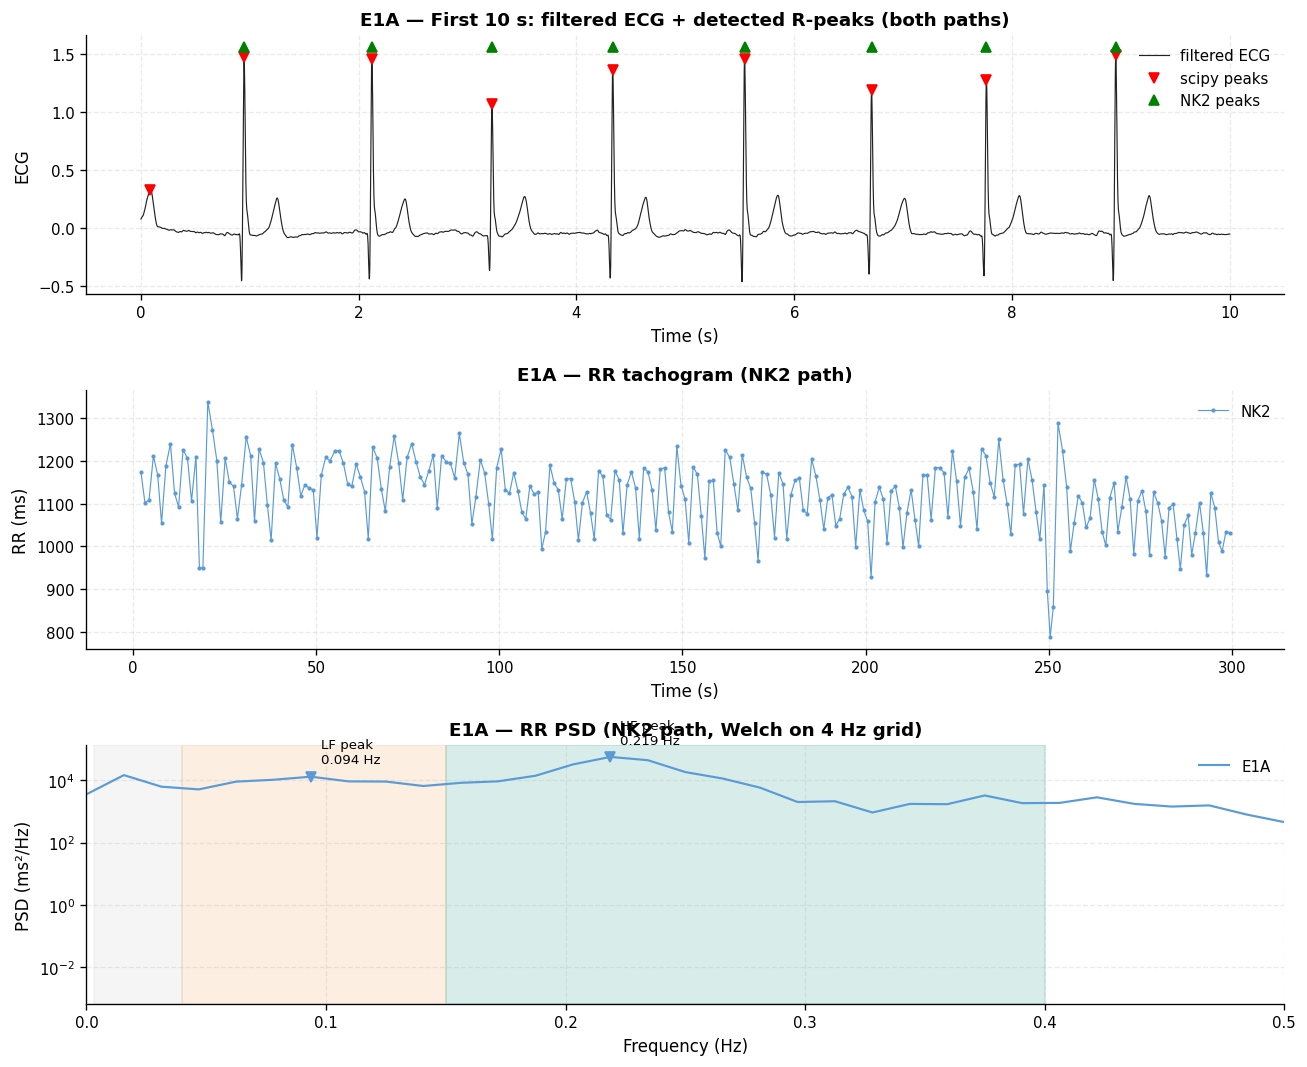

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(11, 9))
seg = slice(0, int(10 * cfg.FS))

axes[0].plot(t[seg], ecg_f[seg], color="#222", linewidth=0.7, label="filtered ECG")
p_in = peaks_s[peaks_s < seg.stop]
axes[0].plot(t[p_in], ecg_f[p_in], "rv", markersize=6, label="scipy peaks")
p_in_nk = peaks_nk[peaks_nk < seg.stop]
axes[0].plot(t[p_in_nk], ecg_f[p_in_nk] * 0 + ecg_f[p_in_nk].max() * 1.05,
             "g^", markersize=6, label="NK2 peaks")
axes[0].set_xlabel("Time (s)"); axes[0].set_ylabel("ECG")
axes[0].set_title("E1A — First 10 s: filtered ECG + detected R-peaks (both paths)")
axes[0].legend(loc="upper right")

PL.plot_rr_tachogram(rr_nk, rt_nk, ax=axes[1],
                     color=PL.STYLE_COLORS[key],
                     title="E1A — RR tachogram (NK2 path)",
                     label="NK2")

f, p = P.rr_psd(rr_nk, rt_nk)
PL.plot_rr_psd_pub(f, p, ax=axes[2], color=PL.STYLE_COLORS[key],
                   title="E1A — RR PSD (NK2 path, Welch on 4 Hz grid)",
                   label="E1A")
fig.tight_layout()
plt.show()

## 9. Save validation table

In [10]:
# Write full 95-index HRV CSV and the comparison table
hrv_full.insert(0, "key", key)
hrv_full.to_csv(TBL_DIR / "e1a_hrv_full.csv", index=False)
df_cmp.to_csv(TBL_DIR / "e1a_pipeline_comparison.csv", index=False)
print(f"Wrote {TBL_DIR/'e1a_hrv_full.csv'}")
print(f"Wrote {TBL_DIR/'e1a_pipeline_comparison.csv'}")

Wrote /Users/wupeien/Developer/hw5_ecg-analysis/outputs/tables/e1a_hrv_full.csv
Wrote /Users/wupeien/Developer/hw5_ecg-analysis/outputs/tables/e1a_pipeline_comparison.csv
